<a href="https://www.kaggle.com/code/gamalelansary/fruits?scriptVersionId=355855765" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, random_split
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass

import kagglehub

In [3]:
shamimhasan8_fruits_dataset_path="/kaggle/input/datasets/shamimhasan8/fruits-dataset"
torch.cuda.is_available()

True

In [4]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

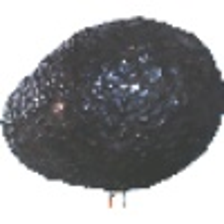

In [5]:
from PIL import Image
import os
image = Image.open(os.path.join(shamimhasan8_fruits_dataset_path, "Fruits Dataset/abacate/Fruit_360-Avocado ripe_113.png")).convert("RGB").resize((224, 224))
image

# Transforms

In [6]:
train_transform=transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform=transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transform=transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Split Dataset

In [7]:
from PIL import UnidentifiedImageError

class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except UnidentifiedImageError:
            return self.__getitem__((index + 1) % len(self))

dataset = SafeImageFolder(root=os.path.join(shamimhasan8_fruits_dataset_path, "Fruits Dataset"), transform=train_transform)
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])
val_set.transform = val_transform
test_set.transform = test_transform

In [9]:
len(dataset.classes)

56

In [10]:
train_loader=DataLoader(train_set, batch_size=64,shuffle=True)
val_loader=DataLoader(val_set, batch_size=64,shuffle=False)
test_loader=DataLoader(test_set, batch_size=64,shuffle=False)

# CNN Classifier

In [23]:
from tqdm.notebook import tqdm

class CNNClass(nn.Module):
    def __init__(self):
        super(CNNClass, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.relu = nn.ReLU()
        self.dropout2d = nn.Dropout2d(p=0.2)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.5)
        self.layer = nn.Linear(128*28*28, 56)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.maxpool(self.relu(self.bn2(self.conv2(x))))
        x = self.maxpool(self.relu(self.bn3(self.conv3(x))))
        x = self.dropout2d(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.layer(x)
        return x

model = CNNClass()
model.to(device)
print(model)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/5 [Train]")
    for images, labels in train_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.detach() * images.size(0)
        _, preds = outputs.max(1)
        train_correct += (preds == labels).sum()
        train_total += labels.size(0)

        running_loss = (train_loss / train_total).item()
        running_acc = (100.0 * train_correct / train_total).item()
        train_bar.set_postfix({"loss": f"{running_loss:.4f}", "accuracy": f"{running_acc:.2f}%"})

    epoch_train_loss = (train_loss / train_total).item()
    epoch_train_acc = (100.0 * train_correct / train_total).item()

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/5 [Val]", leave=False)
    with torch.no_grad():
       for images, labels in val_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.detach() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum()
            val_total += labels.size(0)

            running_val_loss = (val_loss / val_total).item()
            running_val_acc = (100.0 * val_correct / val_total).item()
            val_bar.set_postfix({"loss": f"{running_val_loss:.4f}", "accuracy": f"{running_val_acc:.2f}%"})

    epoch_val_loss = (val_loss / val_total).item()
    epoch_val_acc = (100.0 * val_correct / val_total).item()

    print(f"Epoch {epoch+1} Complete: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%\n")

CNNClass(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer): Linear(in_features=100352, out_features=56, bias=True)
)


Epoch 1/5 [Train]:   0%|          | 0/1216 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/406 [00:00<?, ?it/s]

Epoch 1 Complete: Train Loss: 1.5118, Train Acc: 65.28% | Val Loss: 1.0541, Val Acc: 75.21%



Epoch 2/5 [Train]:   0%|          | 0/1216 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/406 [00:00<?, ?it/s]

Epoch 4 Complete: Train Loss: 0.3105, Train Acc: 91.18% | Val Loss: 1.0229, Val Acc: 80.01%



Epoch 5/5 [Train]:   0%|          | 0/1216 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/406 [00:00<?, ?it/s]

Epoch 5 Complete: Train Loss: 0.2162, Train Acc: 93.73% | Val Loss: 1.0779, Val Acc: 80.50%



In [24]:
from tqdm.notebook import tqdm

model.eval()
test_loss, test_correct, test_total = 0, 0, 0

test_bar = tqdm(test_loader, desc="Evaluating on Test Set")
with torch.no_grad():
    for images, labels in test_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.detach() * images.size(0)
        _, preds = outputs.max(1)
        test_correct += (preds == labels).sum()
        test_total += labels.size(0)

        running_test_loss = (test_loss / test_total).item()
        running_test_acc = (100.0 * test_correct / test_total).item()
        test_bar.set_postfix({"loss": f"{running_test_loss:.4f}", "accuracy": f"{running_test_acc:.2f}%"})

final_test_loss = (test_loss / test_total).item()
final_test_acc = (100.0 * test_correct / test_total).item()

print(f"\nEvaluation Results on Test Dataset:")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%")

Evaluating on Test Set:   0%|          | 0/406 [00:00<?, ?it/s]


Evaluation Results on Test Dataset:
Test Loss: 1.1126
Test Accuracy: 80.25%


# ResNet

In [11]:
from torchvision import models
from tqdm.notebook import tqdm
import torch.nn as nn
import torch.optim as optim

model = models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 56)

model = model.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 3
for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    train_bar = tqdm(train_loader, desc=f"ResNet50 (Frozen Backbone) Epoch {epoch+1}/{epochs} [Train]")
    for images, labels in train_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.detach() * images.size(0)
        _, preds = outputs.max(1)
        train_correct += (preds == labels).sum()
        train_total += labels.size(0)

        running_loss = (train_loss / train_total).item()
        running_acc = (100.0 * train_correct / train_total).item()
        train_bar.set_postfix({"loss": f"{running_loss:.4f}", "accuracy": f"{running_acc:.2f}%"})

    epoch_train_loss = (train_loss / train_total).item()
    epoch_train_acc = (100.0 * train_correct / train_total).item()

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    val_bar = tqdm(val_loader, desc=f"ResNet50 Epoch {epoch+1}/{epochs} [Val]", leave=False)
    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.detach() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum()
            val_total += labels.size(0)

            running_val_loss = (val_loss / val_total).item()
            running_val_acc = (100.0 * val_correct / val_total).item()
            val_bar.set_postfix({"loss": f"{running_val_loss:.4f}", "accuracy": f"{running_val_acc:.2f}%"})

    epoch_val_loss = (val_loss / val_total).item()
    epoch_val_acc = (100.0 * val_correct / val_total).item()

    print(f"ResNet50 (Frozen Backbone) Epoch {epoch+1} Complete: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%\n")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 224MB/s]


ResNet50 (Frozen Backbone) Epoch 1/3 [Train]:   0%|          | 0/1216 [00:00<?, ?it/s]

ResNet50 Epoch 1/3 [Val]:   0%|          | 0/406 [00:00<?, ?it/s]

...

ResNet50 Epoch 2/3 [Val]:   0%|          | 0/406 [00:00<?, ?it/s]

ResNet50 (Frozen Backbone) Epoch 2 Complete: Train Loss: 0.2789, Train Acc: 92.27% | Val Loss: 0.2633, Val Acc: 92.57%



ResNet50 (Frozen Backbone) Epoch 3/3 [Train]:   0%|          | 0/1216 [00:00<?, ?it/s]

ResNet50 Epoch 3/3 [Val]:   0%|          | 0/406 [00:00<?, ?it/s]

ResNet50 (Frozen Backbone) Epoch 3 Complete: Train Loss: 0.2318, Train Acc: 93.46% | Val Loss: 0.2495, Val Acc: 93.34%



In [12]:
from tqdm.notebook import tqdm

model.eval()
test_loss, test_correct, test_total = 0, 0, 0

test_bar = tqdm(test_loader, desc="Evaluating on Test Set")
with torch.no_grad():
    for images, labels in test_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.detach() * images.size(0)
        _, preds = outputs.max(1)
        test_correct += (preds == labels).sum()
        test_total += labels.size(0)

        running_test_loss = (test_loss / test_total).item()
        running_test_acc = (100.0 * test_correct / test_total).item()
        test_bar.set_postfix({"loss": f"{running_test_loss:.4f}", "accuracy": f"{running_test_acc:.2f}%"})

final_test_loss = (test_loss / test_total).item()
final_test_acc = (100.0 * test_correct / test_total).item()

print(f"\nEvaluation Results on Test Dataset:")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%")

Evaluating on Test Set:   0%|          | 0/406 [00:00<?, ?it/s]


Evaluation Results on Test Dataset:
Test Loss: 0.2391
Test Accuracy: 93.50%


In [14]:
torch.save(model.state_dict(), "/kaggle/working/fruit_model.pth")

In [ ]:
model = models.resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 56)
model.load_state_dict(torch.load("fruit_resnet50_model.pth"))